In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [8]:
VOCAB_SIZE = 20000
MAX_LEN = 250
EMBED_DIM = 128
BATCH_SIZE = 64
EPOCHS = 10

In [9]:
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(
    num_words=VOCAB_SIZE
)

x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

x_val = x_train[:5000]
y_val = y_train[:5000]

x_train = x_train[5000:]
y_train = y_train[5000:]

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (20000, 250)
Validation: (5000, 250)
Test: (25000, 250)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 250, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,576,641 (9.83 MB)

 Trainable params: 2,576,641 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7441 - loss: 0.5045 - val_accuracy: 0.8526 - val_loss: 0.3447
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8880 - loss: 0.2755 - val_accuracy: 0.8836 - val_loss: 0.2917
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9233 - loss: 0.1952 - val_accuracy: 0.8452 - val_loss: 0.3839
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9434 - loss: 0.1545 - val_accuracy: 0.8836 - val_loss: 0.3064
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9600 - loss: 0.1178 - val_accuracy: 0.8900 - val_loss: 0.3107
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9621 - loss: 0.1116 - val_accuracy: 0.8862 - val_loss: 0.3268
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9751 - loss: 0.0802 - val_accuracy: 0.8734 - val_loss: 0.3879
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9713 - loss: 0.0815 - va

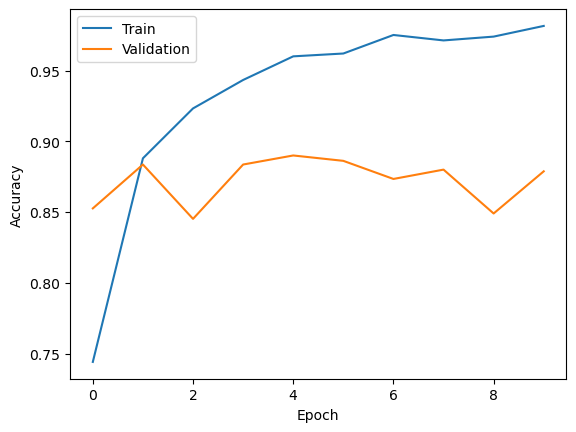

In [10]:
inputs = keras.Input(shape=(MAX_LEN,))

x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation="relu")(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)


loss, acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy : {acc:.4f}")


plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_2 (Embedding)              │ (None, 250, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 246, 128)            │          82,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,642,177 (10.08 MB)

 Trainable params: 2,642,177 (10.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - accuracy: 0.7726 - loss: 0.4606 - val_accuracy: 0.8690 - val_loss: 0.3104
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.9146 - loss: 0.2246 - val_accuracy: 0.8820 - val_loss: 0.2847
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.9698 - loss: 0.0998 - val_accuracy: 0.8846 - val_loss: 0.2888
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9952 - loss: 0.0317 - val_accuracy: 0.8884 - val_loss: 0.3189
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9994 - loss: 0.0094 - val_accuracy: 0.8866 - val_loss: 0.3542
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9999 - loss: 0.0035 - val_accuracy: 0.8886 - val_loss: 0.3752
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8892 - val_loss: 0.3962
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 88ms/step - accuracy: 1.0000 - loss: 0.0010 - 

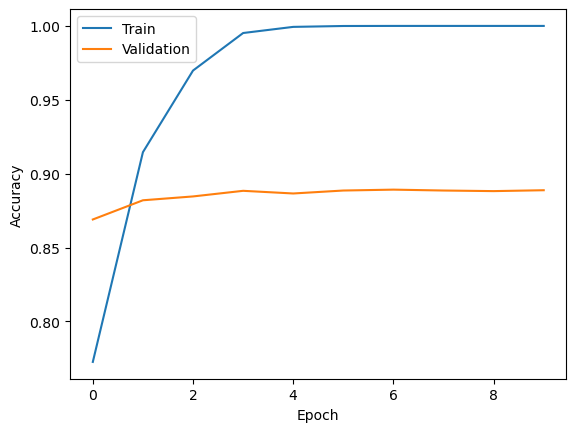

In [11]:
inputs = keras.Input(shape=(MAX_LEN,))

x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)

x = layers.Conv1D(128, 5, activation="relu")(x)
x = layers.GlobalMaxPooling1D()(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)


loss, acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy : {acc:.4f}")


plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_3 (Embedding)              │ (None, 250, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,580,641 (9.84 MB)

 Trainable params: 2,580,641 (9.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 169ms/step - accuracy: 0.7927 - loss: 0.4351 - val_accuracy: 0.8704 - val_loss: 0.3200
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.9115 - loss: 0.2300 - val_accuracy: 0.8768 - val_loss: 0.3124
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.9506 - loss: 0.1372 - val_accuracy: 0.8710 - val_loss: 0.3596
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 193ms/step - accuracy: 0.9693 - loss: 0.0914 - val_accuracy: 0.8430 - val_loss: 0.4390
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 134ms/step - accuracy: 0.9763 - loss: 0.0703 - val_accuracy: 0.8448 - val_loss: 0.4653
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9849 - loss: 0.0484 - val_accuracy: 0.8616 - val_loss: 0.5191
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 165ms/step - accuracy: 0.9846 - loss: 0.0475 - val_accuracy: 0.8504 - val_loss: 0.5120
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.9919 - loss: 0.0

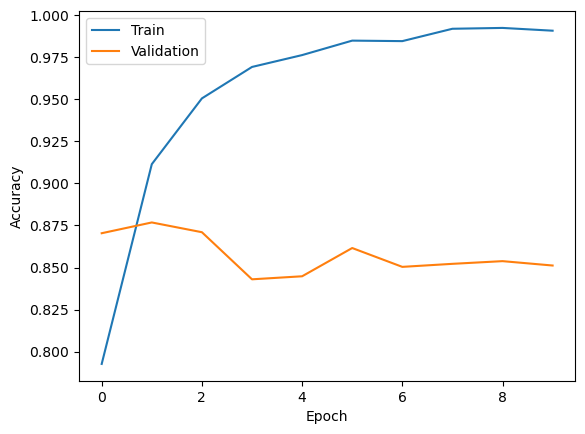

In [13]:
inputs = keras.Input(shape=(MAX_LEN,))

x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)

x = layers.LSTM(32)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)


model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)


loss, acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy : {acc:.4f}")


plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
NUM_HEADS = 2
FF_DIM = 32

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.layernorm2(out1 + ffn_output)

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

inputs = keras.Input(shape=(MAX_LEN,))
x = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBED_DIM)(inputs)
x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(20, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy : {acc:.4f}")

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ token_and_position_embedding         │ (None, 250, 128)            │       2,592,000 │
│ (TokenAndPositionEmbedding)          │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block (TransformerBlock) │ (None, 250, 128)            │         140,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 20)                  │           2,580 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,735,433 (10.43 MB)

 Trainable params: 2,735,433 (10.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
304/313 ━━━━━━━━━━━━━━━━━━━━ 3s 359ms/step - accuracy: 0.7461 - loss: 0.4611  